# Style Transfer with Deep Neural Networks


In this notebook, we’ll *recreate* a style transfer method that is outlined in the paper, [Image Style Transfer Using Convolutional Neural Networks, by Gatys](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/Gatys_Image_Style_Transfer_CVPR_2016_paper.pdf) in PyTorch.

In this notebook, we'll use a pre-trained VGG19 Net to extract content or style features from a passed in image. We'll then formalize the idea of content and style _losses_ and use those to iteratively update our target image until we get a result that we want. You are encouraged to use a style and content image of your own.

In [1]:
# import resources
%matplotlib inline

from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.optim as optim
import requests
from torchvision import transforms, models

## Load in VGG19 (features)

VGG19 is split into two portions:
* `vgg19.features`, which are all the convolutional and pooling layers
* `vgg19.classifier`, which are the three linear, classifier layers at the end

We only need the `features` portion, which we're going to load in and "freeze" the weights of, below.

In [2]:
# get the "features" portion of VGG19 (we will not need the "classifier" portion)
vgg = models.vgg19(pretrained=True).features

# freeze all VGG parameters since we're only optimizing the target image
for param in vgg.parameters():
    param.requires_grad_(False)

/Users/rauankkhithani/Desktop/MS/608-DataScience/608env/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/rauankkhithani/Desktop/MS/608-DataScience/608env/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [3]:
# move the model to GPU, if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg.to(device)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

### Load in Content and Style Images

You can load in any images you want! Below, we've provided a helper function for loading in any type and size of image. The `load_image` function also converts images to normalized Tensors.

Additionally, it will be easier to have smaller images and to squish the content and style images so that they are of the same size.

In [4]:
def load_image(img_path, max_size=400, shape=None):
    ''' Load in and transform an image, making sure the image
       is <= 400 pixels in the x-y dims.'''
    if "http" in img_path:
        response = requests.get(img_path)
        image = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        image = Image.open(img_path).convert('RGB')
    
    # large images will slow down processing
    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)
    
    if shape is not None:
        size = shape
        
    in_transform = transforms.Compose([
                        transforms.Resize(size),
                        transforms.ToTensor(),
                        transforms.Normalize((0.485, 0.456, 0.406), 
                                             (0.229, 0.224, 0.225))])

    # discard the transparent, alpha channel (that's the :3) and add the batch dimension
    image = in_transform(image)[:3,:,:].unsqueeze(0)
    
    return image

Next, I'm loading in images by file name and forcing the style image to be the same size as the content image.

**TODO**: use your content vs style images.

In [5]:
# load in content and style image
content = load_image('content.jpeg').to(device)
# Resize style to match content, makes code easier
style = load_image('style.png', shape=content.shape[-2:]).to(device)

In [6]:
# helper function for un-normalizing an image 
# and converting it from a Tensor image to a NumPy image for display
def im_convert(tensor):
    """ Display a tensor as an image. """
    
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1,2,0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)

    return image

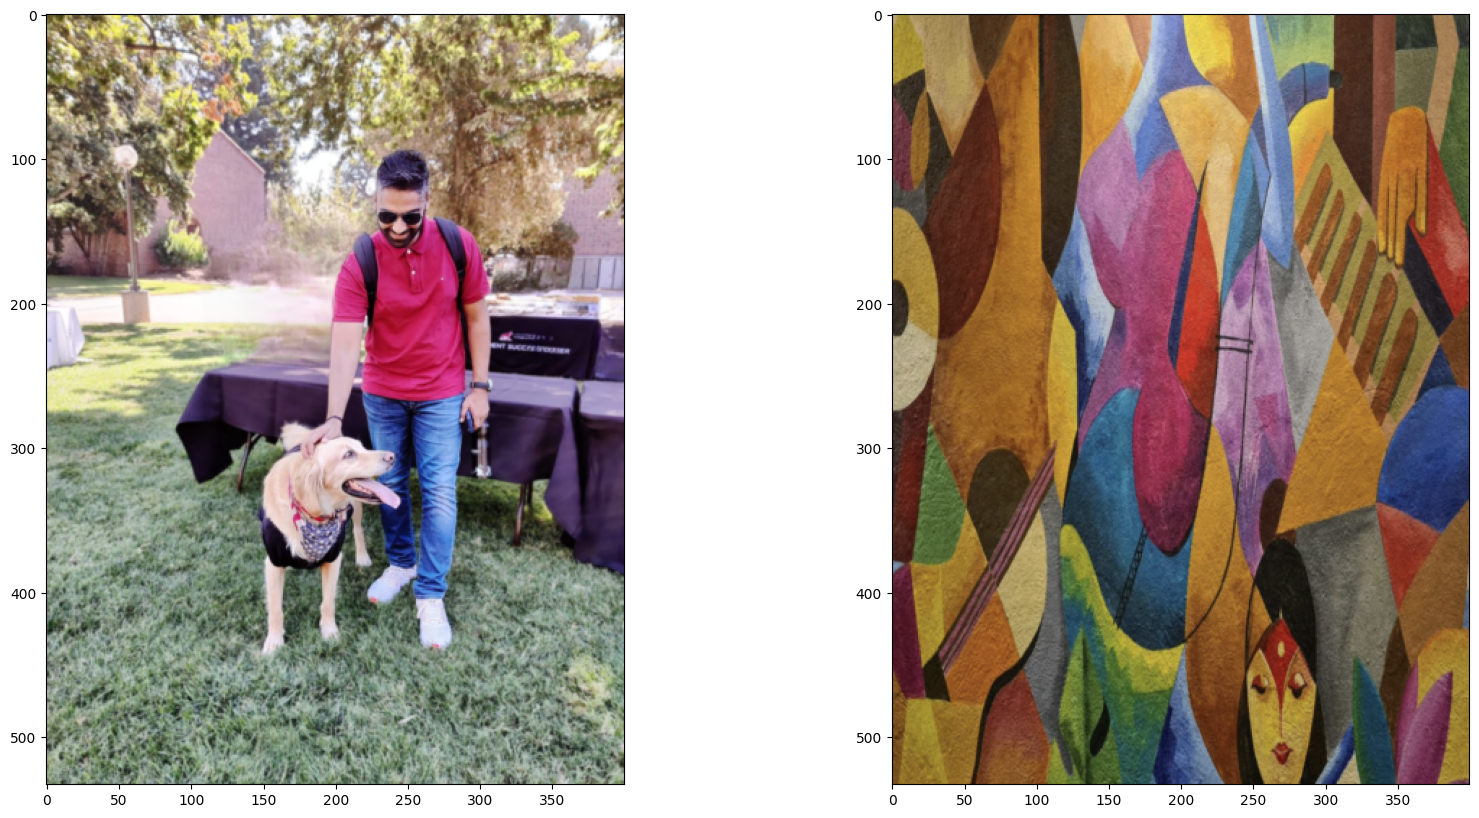

In [7]:
# display the images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
# content and style ims side-by-side
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(style))

---
## VGG19 Layers

To get the content and style representations of an image, we have to pass an image forward through the VGG19 network until we get to the desired layer(s) and then get the output from that layer.

In [8]:
# print out VGG19 structure so you can see the names of various layers
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

## Content and Style Features

#### **TODO**: complete the mapping of layer names to the names found in the paper for the _content representation_ and the _style representation_.

The first layer (0) to `conv1_1` has been done for you, below.

In [9]:

def get_features(image, model, layers=None):
    """ Run an image forward through a model and get the features for 
        a set of layers. Default layers are for VGGNet matching Gatys et al (2016)
    """
    #remove for priyanka
    
    ## TODO: Complete mapping layer names of PyTorch's VGGNet to names from the paper
    ## Need the layers for the content and style representations of an image
    if layers is None:
        layers = {
                    #style
                    '0': 'conv1_1',
                    '5': 'conv2_1',
                    '10': 'conv3_1',
                    '19': 'conv4_1',
                    '28': 'conv5_1',

                    #content
                    '2': 'conv1_2',
                    '7': 'conv2_2',
                    '12': 'conv3_2',
                    '21': 'conv4_2',
                    '30': 'conv5_2',
                    '34': 'conv5_4',
                }

    ## -- do not need to change the code below this line -- ##
    features = {}
    x = image
    # model._modules is a dictionary holding each module in the model
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
            
    return features

---
## Gram Matrix 

The output of every convolutional layer is a Tensor with dimensions associated with the `batch_size`, a depth, `d` and some height and width (`h`, `w`). The Gram matrix of a convolutional layer can be calculated as follows:
* Get the depth, height, and width of a tensor using `batch_size, d, h, w = tensor.size()`
* Reshape that tensor so that the spatial dimensions are flattened
* Calculate the gram matrix by multiplying the reshaped tensor by it's transpose 

*Note: You can multiply two matrices using `torch.mm(matrix1, matrix2)`.*

#### TODO: Complete the `gram_matrix` function.

In [10]:
def gram_matrix(tensor):
    """ Calculate the Gram Matrix of a given tensor 
        Gram Matrix: https://en.wikipedia.org/wiki/Gramian_matrix
    """ 
    
    ## get the batch_size, depth, height, and width of the Tensor
    _, d, h, w = tensor.size()
    
    ## reshape it, so we're multiplying the features for each channel
    tensor_reshaped = tensor.view(d,h*w)
    ## calculate the gram matrix
    gram = torch.mm(tensor_reshaped, tensor_reshaped.t())
    #gram = None
    
    return gram 

## Putting it all Together

Now that we've written functions for extracting features and computing the gram matrix of a given convolutional layer; let's put all these pieces together! We'll extract our features from our images and calculate the gram matrices for each layer in our style representation.

In [11]:
# get content and style features only once before forming the target image
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

# calculate the gram matrices for each layer of our style representation
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# create a third "target" image and prep it for change
# it is a good idea to start off with the target as a copy of our *content* image
# then iteratively change its style
target = content.clone().requires_grad_(True).to(device)

---
## Loss and Weights

#### Individual Layer Style Weights

Below, you are given the option to weight the style representation at each relevant layer. It's suggested that you use a range between 0-1 to weight these layers. By weighting earlier layers (`conv1_1` and `conv2_1`) more, you can expect to get _larger_ style artifacts in your resulting, target image. Should you choose to weight later layers, you'll get more emphasis on smaller features. This is because each layer is a different size and together they create a multi-scale style representation!

#### Content and Style Weight

Just like in the paper, we define an alpha (`content_weight`) and a beta (`style_weight`). This ratio will affect how _stylized_ your final image is. It's recommended that you leave the content_weight = 1 and set the style_weight to achieve the ratio you want.

In [12]:
# weights for each style layer 
# weighting earlier layers more will result in *larger* style artifacts
# notice we are excluding `conv4_2` our content representation
style_weights = {'conv1_1': 1.,
                 'conv2_1': 0.8,
                 'conv3_1': 0.5,
                 'conv4_1': 0.3,
                 'conv5_1': 0.1}

# you may choose to leave these as is
content_weight = 1  # alpha
style_weight = 1e6  # beta

## Updating the Target & Calculating Losses

You'll decide on a number of steps for which to update your image, this is similar to the training loop that you've seen before, only we are changing our _target_ image and nothing else about VGG19 or any other image. Therefore, the number of steps is really up to you to set! **I recommend using at least 2000 steps for good results.** But, you may want to start out with fewer steps if you are just testing out different weight values or experimenting with different images.

Inside the iteration loop, you'll calculate the content and style losses and update your target image, accordingly.

#### Content Loss

The content loss will be the mean squared difference between the target and content features at layer `conv4_2`. This can be calculated as follows: 
```
content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)
```

#### Style Loss

The style loss is calculated in a similar way, only you have to iterate through a number of layers, specified by name in our dictionary `style_weights`. 
> You'll calculate the gram matrix for the target image, `target_gram` and style image `style_gram` at each of these layers and compare those gram matrices, calculating the `layer_style_loss`. 
> Later, you'll see that this value is normalized by the size of the layer.

#### Total Loss

Finally, you'll create the total loss by adding up the style and content losses and weighting them with your specified alpha and beta!

Intermittently, we'll print out this loss; don't be alarmed if the loss is very large. It takes some time for an image's style to change and you should focus on the appearance of your target image rather than any loss value. Still, you should see that this loss decreases over some number of iterations.

#### TODO: Define content, style, and total losses.

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 277 

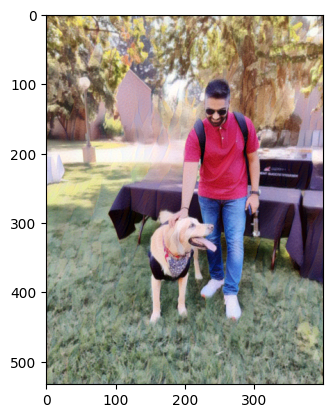

401 402 403 404 405 406 407 408 409 410 411 412 413 414 415 416 417 418 419 420 421 422 423 424 425 426 427 428 429 430 431 432 433 434 435 436 437 438 439 440 441 442 443 444 445 446 447 448 449 450 451 452 453 454 455 456 457 458 459 460 461 462 463 464 465 466 467 468 469 470 471 472 473 474 475 476 477 478 479 480 481 482 483 484 485 486 487 488 489 490 491 492 493 494 495 496 497 498 499 500 501 502 503 504 505 506 507 508 509 510 511 512 513 514 515 516 517 518 519 520 521 522 523 524 525 526 527 528 529 530 531 532 533 534 535 536 537 538 539 540 541 542 543 544 545 546 547 548 549 550 551 552 553 554 555 556 557 558 559 560 561 562 563 564 565 566 567 568 569 570 571 572 573 574 575 576 577 578 579 580 581 582 583 584 585 586 587 588 589 590 591 592 593 594 595 596 597 598 599 600 601 602 603 604 605 606 607 608 609 610 611 612 613 614 615 616 617 618 619 620 621 622 623 624 625 626 627 628 629 630 631 632 633 634 635 636 637 638 639 640 641 642 643 644 645 646 647 648 649 650 

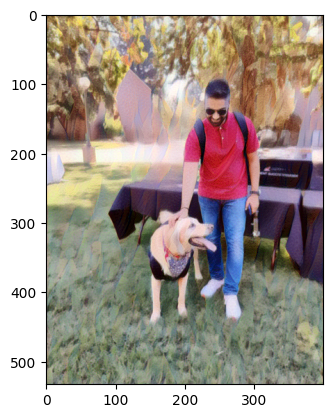

801 802 803 804 805 806 807 808 809 810 811 812 813 814 815 816 817 818 819 820 821 822 823 824 825 826 827 828 829 830 831 832 833 834 835 836 837 838 839 840 841 842 843 844 845 846 847 848 849 850 851 852 853 854 855 856 857 858 859 860 861 862 863 864 865 866 867 868 869 870 871 872 873 874 875 876 877 878 879 880 881 882 883 884 885 886 887 888 889 890 891 892 893 894 895 896 897 898 899 900 901 902 903 904 905 906 907 908 909 910 911 912 913 914 915 916 917 918 919 920 921 922 923 924 925 926 927 928 929 930 931 932 933 934 935 936 937 938 939 940 941 942 943 944 945 946 947 948 949 950 951 952 953 954 955 956 957 958 959 960 961 962 963 964 965 966 967 968 969 970 971 972 973 974 975 976 977 978 979 980 981 982 983 984 985 986 987 988 989 990 991 992 993 994 995 996 997 998 999 1000 1001 1002 1003 1004 1005 1006 1007 1008 1009 1010 1011 1012 1013 1014 1015 1016 1017 1018 1019 1020 1021 1022 1023 1024 1025 1026 1027 1028 1029 1030 1031 1032 1033 1034 1035 1036 1037 1038 1039 1040

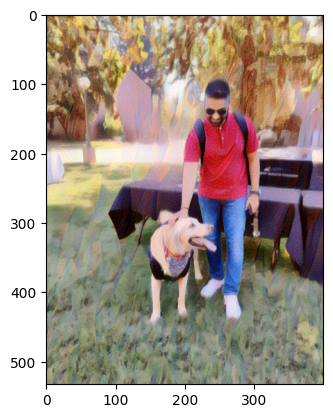

1201 1202 1203 1204 1205 1206 1207 1208 1209 1210 1211 1212 1213 1214 1215 1216 1217 1218 1219 1220 1221 1222 1223 1224 1225 1226 1227 1228 1229 1230 1231 1232 1233 1234 1235 1236 1237 1238 1239 1240 1241 1242 1243 1244 1245 1246 1247 1248 1249 1250 1251 1252 1253 1254 1255 1256 1257 1258 1259 1260 1261 1262 1263 1264 1265 1266 1267 1268 1269 1270 1271 1272 1273 1274 1275 1276 1277 1278 1279 1280 1281 1282 1283 1284 1285 1286 1287 1288 1289 1290 1291 1292 1293 1294 1295 1296 1297 1298 1299 1300 1301 1302 1303 1304 1305 1306 1307 1308 1309 1310 1311 1312 1313 1314 1315 1316 1317 1318 1319 1320 1321 1322 1323 1324 1325 1326 1327 1328 1329 1330 1331 1332 1333 1334 1335 1336 1337 1338 1339 1340 1341 1342 1343 1344 1345 1346 1347 1348 1349 1350 1351 1352 1353 1354 1355 1356 1357 1358 1359 1360 1361 1362 1363 1364 1365 1366 1367 1368 1369 1370 1371 1372 1373 1374 1375 1376 1377 1378 1379 1380 1381 1382 1383 1384 1385 1386 1387 1388 1389 1390 1391 1392 1393 1394 1395 1396 1397 1398 1399 1400 

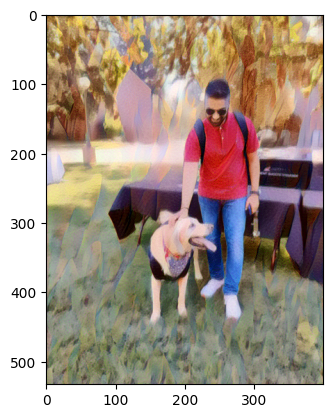

1601 1602 1603 1604 1605 1606 1607 1608 1609 1610 1611 1612 1613 1614 1615 1616 1617 1618 1619 1620 1621 1622 1623 1624 1625 1626 1627 1628 1629 1630 1631 1632 1633 1634 1635 1636 1637 1638 1639 1640 1641 1642 1643 1644 1645 1646 1647 1648 1649 1650 1651 1652 1653 1654 1655 1656 1657 1658 1659 1660 1661 1662 1663 1664 1665 1666 1667 1668 1669 1670 1671 1672 1673 1674 1675 1676 1677 1678 1679 1680 1681 1682 1683 1684 1685 1686 1687 1688 1689 1690 1691 1692 1693 1694 1695 1696 1697 1698 1699 1700 1701 1702 1703 1704 1705 1706 1707 1708 1709 1710 1711 1712 1713 1714 1715 1716 1717 1718 1719 1720 1721 1722 1723 1724 1725 1726 1727 1728 1729 1730 1731 1732 1733 1734 1735 1736 1737 1738 1739 1740 1741 1742 1743 1744 1745 1746 1747 1748 1749 1750 1751 1752 1753 1754 1755 1756 1757 1758 1759 1760 1761 1762 1763 1764 1765 1766 1767 1768 1769 1770 1771 1772 1773 1774 1775 1776 1777 1778 1779 1780 1781 1782 1783 1784 1785 1786 1787 1788 1789 1790 1791 1792 1793 1794 1795 1796 1797 1798 1799 1800 

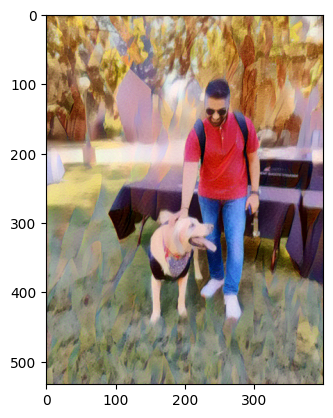

2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054 2055 2056 2057 2058 2059 2060 2061 2062 2063 2064 2065 2066 2067 2068 2069 2070 2071 2072 2073 2074 2075 2076 2077 2078 2079 2080 2081 2082 2083 2084 2085 2086 2087 2088 2089 2090 2091 2092 2093 2094 2095 2096 2097 2098 2099 2100 2101 2102 2103 2104 2105 2106 2107 2108 2109 2110 2111 2112 2113 2114 2115 2116 2117 2118 2119 2120 2121 2122 2123 2124 2125 2126 2127 2128 2129 2130 2131 2132 2133 2134 2135 2136 2137 2138 2139 2140 2141 2142 2143 2144 2145 2146 2147 2148 2149 2150 2151 2152 2153 2154 2155 2156 2157 2158 2159 2160 2161 2162 2163 2164 2165 2166 2167 2168 2169 2170 2171 2172 2173 2174 2175 2176 2177 2178 2179 2180 2181 2182 2183 2184 2185 2186 2187 2188 2189 2190 2191 2192 2193 2194 2195 2196 2197 2198 2199 2200 

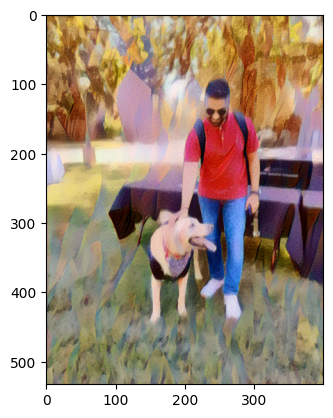

2401 2402 2403 2404 2405 2406 2407 2408 2409 2410 2411 2412 2413 2414 2415 2416 2417 2418 2419 2420 2421 2422 2423 2424 2425 2426 2427 2428 2429 2430 2431 2432 2433 2434 2435 2436 2437 2438 2439 2440 2441 2442 2443 2444 2445 2446 2447 2448 2449 2450 2451 2452 2453 2454 2455 2456 2457 2458 2459 2460 2461 2462 2463 2464 2465 2466 2467 2468 2469 2470 2471 2472 2473 2474 2475 2476 2477 2478 2479 2480 2481 2482 2483 2484 2485 2486 2487 2488 2489 2490 2491 2492 2493 2494 2495 2496 2497 2498 2499 2500 2501 2502 2503 2504 2505 2506 2507 2508 2509 2510 2511 2512 2513 2514 2515 2516 2517 2518 2519 2520 2521 2522 2523 2524 2525 2526 2527 2528 2529 2530 2531 2532 2533 2534 2535 2536 2537 2538 2539 2540 2541 2542 2543 2544 2545 2546 2547 2548 2549 2550 2551 2552 2553 2554 2555 2556 2557 2558 2559 2560 2561 2562 2563 2564 2565 2566 2567 2568 2569 2570 2571 2572 2573 2574 2575 2576 2577 2578 2579 2580 2581 2582 2583 2584 2585 2586 2587 2588 2589 2590 2591 2592 2593 2594 2595 2596 2597 2598 2599 2600 

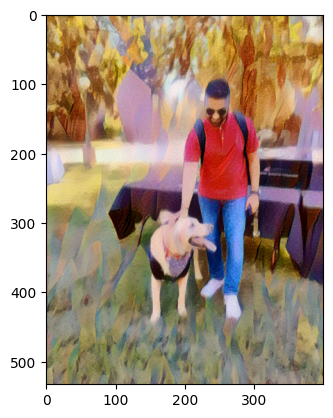

2801 2802 2803 2804 2805 2806 2807 2808 2809 2810 2811 2812 2813 2814 2815 2816 2817 2818 2819 2820 2821 2822 2823 2824 2825 2826 2827 2828 2829 2830 2831 2832 2833 2834 2835 2836 2837 2838 2839 2840 2841 2842 2843 2844 2845 2846 2847 2848 2849 2850 2851 2852 2853 2854 2855 2856 2857 2858 2859 2860 2861 2862 2863 2864 2865 2866 2867 2868 2869 2870 2871 2872 2873 2874 2875 2876 2877 2878 2879 2880 2881 2882 2883 2884 2885 2886 2887 2888 2889 2890 2891 2892 2893 2894 2895 2896 2897 2898 2899 2900 2901 2902 2903 2904 2905 2906 2907 2908 2909 2910 2911 2912 2913 2914 2915 2916 2917 2918 2919 2920 2921 2922 2923 2924 2925 2926 2927 2928 2929 2930 2931 2932 2933 2934 2935 2936 2937 2938 2939 2940 2941 2942 2943 2944 2945 2946 2947 2948 2949 2950 2951 2952 2953 2954 2955 2956 2957 2958 2959 2960 2961 2962 2963 2964 2965 2966 2967 2968 2969 2970 2971 2972 2973 2974 2975 2976 2977 2978 2979 2980 2981 2982 2983 2984 2985 2986 2987 2988 2989 2990 2991 2992 2993 2994 2995 2996 2997 2998 2999 3000 

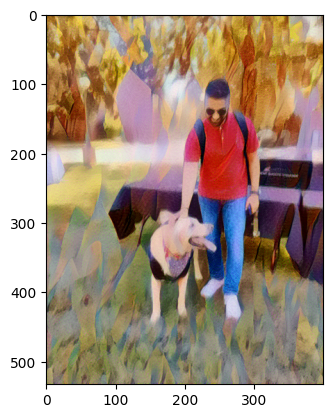

3201 3202 3203 3204 3205 3206 3207 3208 3209 3210 3211 3212 3213 3214 3215 3216 3217 3218 3219 3220 3221 3222 3223 3224 3225 3226 3227 3228 3229 3230 3231 3232 3233 3234 3235 3236 3237 3238 3239 3240 3241 3242 3243 3244 3245 3246 3247 3248 3249 3250 3251 3252 3253 3254 3255 3256 3257 3258 3259 3260 3261 3262 3263 3264 3265 3266 3267 3268 3269 3270 3271 3272 3273 3274 3275 3276 3277 3278 3279 3280 3281 3282 3283 3284 3285 3286 3287 3288 3289 3290 3291 3292 3293 3294 3295 3296 3297 3298 3299 3300 3301 3302 3303 3304 3305 3306 3307 3308 3309 3310 3311 3312 3313 3314 3315 3316 3317 3318 3319 3320 3321 3322 3323 3324 3325 3326 3327 3328 3329 3330 3331 3332 3333 3334 3335 3336 3337 3338 3339 3340 3341 3342 3343 3344 3345 3346 3347 3348 3349 3350 3351 3352 3353 3354 3355 3356 3357 3358 3359 3360 3361 3362 3363 3364 3365 3366 3367 3368 3369 3370 3371 3372 3373 3374 3375 3376 3377 3378 3379 3380 3381 3382 3383 3384 3385 3386 3387 3388 3389 3390 3391 3392 3393 3394 3395 3396 3397 3398 3399 3400 

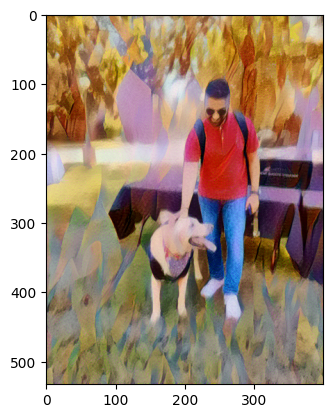

3601 3602 3603 3604 3605 3606 3607 3608 3609 3610 3611 3612 3613 3614 3615 3616 3617 3618 3619 3620 3621 3622 3623 3624 3625 3626 3627 3628 3629 3630 3631 3632 3633 3634 3635 3636 3637 3638 3639 3640 3641 3642 3643 3644 3645 3646 3647 3648 3649 3650 3651 3652 3653 3654 3655 3656 3657 3658 3659 3660 3661 3662 3663 3664 3665 3666 3667 3668 3669 3670 3671 3672 3673 3674 3675 3676 3677 3678 3679 3680 3681 3682 3683 3684 3685 3686 3687 3688 3689 3690 3691 3692 3693 3694 3695 3696 3697 3698 3699 3700 3701 3702 3703 3704 3705 3706 3707 3708 3709 3710 3711 3712 3713 3714 3715 3716 3717 3718 3719 3720 3721 3722 3723 3724 3725 3726 3727 3728 3729 3730 3731 3732 3733 3734 3735 3736 3737 3738 3739 3740 3741 3742 3743 3744 3745 3746 3747 3748 3749 3750 3751 3752 3753 3754 3755 3756 3757 3758 3759 3760 3761 3762 3763 3764 3765 3766 3767 3768 3769 3770 3771 3772 3773 3774 3775 3776 3777 3778 3779 3780 3781 3782 3783 3784 3785 3786 3787 3788 3789 3790 3791 3792 3793 3794 3795 3796 3797 3798 3799 3800 

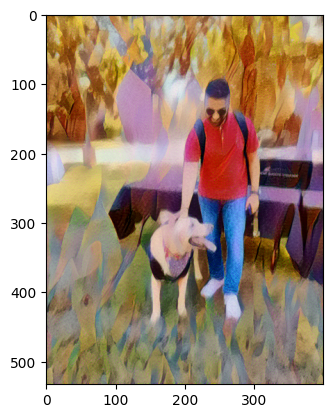

4001 4002 4003 4004 4005 4006 4007 4008 4009 4010 4011 4012 4013 4014 4015 4016 4017 4018 4019 4020 4021 4022 4023 4024 4025 4026 4027 4028 4029 4030 4031 4032 4033 4034 4035 4036 4037 4038 4039 4040 4041 4042 4043 4044 4045 4046 4047 4048 4049 4050 4051 4052 4053 4054 4055 4056 4057 4058 4059 4060 4061 4062 4063 4064 4065 4066 4067 4068 4069 4070 4071 4072 4073 4074 4075 4076 4077 4078 4079 4080 4081 4082 4083 4084 4085 4086 4087 4088 4089 4090 4091 4092 4093 4094 4095 4096 4097 4098 4099 4100 4101 4102 4103 4104 4105 4106 4107 4108 4109 4110 4111 4112 4113 4114 4115 4116 4117 4118 4119 4120 4121 4122 4123 4124 4125 4126 4127 4128 4129 4130 4131 4132 4133 4134 4135 4136 4137 4138 4139 4140 4141 4142 4143 4144 4145 4146 4147 4148 4149 4150 4151 4152 4153 4154 4155 4156 4157 4158 4159 4160 4161 4162 4163 4164 4165 4166 4167 4168 4169 4170 4171 4172 4173 4174 4175 4176 4177 4178 4179 4180 4181 4182 4183 4184 4185 4186 4187 4188 4189 4190 4191 4192 4193 4194 4195 4196 4197 4198 4199 4200 

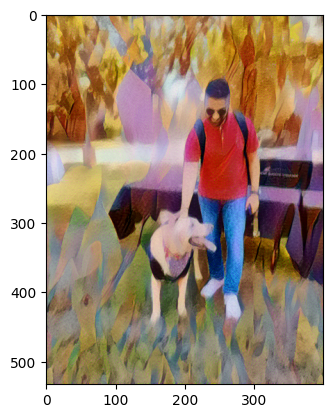

4401 4402 4403 4404 4405 4406 4407 4408 4409 4410 4411 4412 4413 4414 4415 4416 4417 4418 4419 4420 4421 4422 4423 4424 4425 4426 4427 4428 4429 4430 4431 4432 4433 4434 4435 4436 4437 4438 4439 4440 4441 4442 4443 4444 4445 4446 4447 4448 4449 4450 4451 4452 4453 4454 4455 4456 4457 4458 4459 4460 4461 4462 4463 4464 4465 4466 4467 4468 4469 4470 4471 4472 4473 4474 4475 4476 4477 4478 4479 4480 4481 4482 4483 4484 4485 4486 4487 4488 4489 4490 4491 4492 4493 4494 4495 4496 4497 4498 4499 4500 4501 4502 4503 4504 4505 4506 4507 4508 4509 4510 4511 4512 4513 4514 4515 4516 4517 4518 4519 4520 4521 4522 4523 4524 4525 4526 4527 4528 4529 4530 4531 4532 4533 4534 4535 4536 4537 4538 4539 4540 4541 4542 4543 4544 4545 4546 4547 4548 4549 4550 4551 4552 4553 4554 4555 4556 4557 4558 4559 4560 4561 4562 4563 4564 4565 4566 4567 4568 4569 4570 4571 4572 4573 4574 4575 4576 4577 4578 4579 4580 4581 4582 4583 4584 4585 4586 4587 4588 4589 4590 4591 4592 4593 4594 4595 4596 4597 4598 4599 4600 

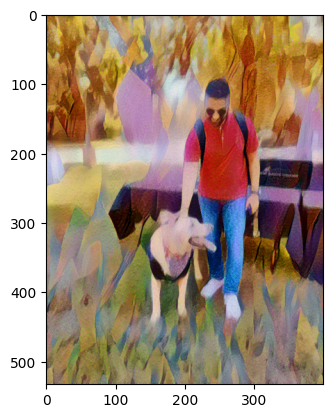

4801 4802 4803 4804 4805 4806 4807 4808 4809 4810 4811 4812 4813 4814 4815 4816 4817 4818 4819 4820 4821 4822 4823 4824 4825 4826 4827 4828 4829 4830 4831 4832 4833 4834 4835 4836 4837 4838 4839 4840 4841 4842 4843 4844 4845 4846 4847 4848 4849 4850 4851 4852 4853 4854 4855 4856 4857 4858 4859 4860 4861 4862 4863 4864 4865 4866 4867 4868 4869 4870 4871 4872 4873 4874 4875 4876 4877 4878 4879 4880 4881 4882 4883 4884 4885 4886 4887 4888 4889 4890 4891 4892 4893 4894 4895 4896 4897 4898 4899 4900 4901 4902 4903 4904 4905 4906 4907 4908 4909 4910 4911 4912 4913 4914 4915 4916 4917 4918 4919 4920 4921 4922 4923 4924 4925 4926 4927 4928 4929 4930 4931 4932 4933 4934 4935 4936 4937 4938 4939 4940 4941 4942 4943 4944 4945 4946 4947 4948 4949 4950 4951 4952 4953 4954 4955 4956 4957 4958 4959 4960 4961 4962 4963 4964 4965 4966 4967 4968 4969 4970 4971 4972 4973 4974 4975 4976 4977 4978 4979 4980 4981 4982 4983 4984 4985 4986 4987 4988 4989 4990 4991 4992 4993 4994 4995 4996 4997 4998 4999 5000 

In [13]:
# for displaying the target image, intermittently
show_every = 400

# iteration hyperparameters
optimizer = optim.Adam([target], lr=0.001)
steps = 5000  # decide how many iterations to update your image (5000)

for ii in range(1, steps+1):
    print(ii, end=" ") #remove for priyanka
    ## TODO: get the features from your target image    
    ## Then calculate the content loss
    target_features = get_features(target, vgg)
    content_loss = torch.mean((target_features['conv5_4'] - content_features['conv5_4'])**2)
    
    # the style loss
    # initialize the style loss to 0
    style_loss = 0
    # iterate through each style layer and add to the style loss
    for layer in style_weights:
        # get the "target" style representation for the layer
        #print(style_weights[layer])
        #break
        target_feature = target_features[layer]
        _, d, h, w = target_feature.shape
        
        ## TODO: Calculate the target gram matrix
        target_gram = gram_matrix(target_feature)
        
        ## TODO:  get the "style" style representation
        style_gram = style_grams[layer]
        ## TODO: Calculate the style loss for one layer, weighted appropriately
        layer_style_loss = torch.mean((target_gram - style_gram)**2)
        
        # add to the style loss
        style_loss += (layer_style_loss / (d * h * w)) * style_weights[layer]
        
        
    ## TODO:  calculate the *total* loss
    total_loss = content_weight*content_loss + style_weight*style_loss
    
    ## -- do not need to change code, below -- ##
    # update your target image
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # display intermediate images and print the loss
    if  ii % show_every == 0:
        print('Total loss: ', total_loss.item())
        plt.imshow(im_convert(target))
        plt.show()

## Display the Target Image

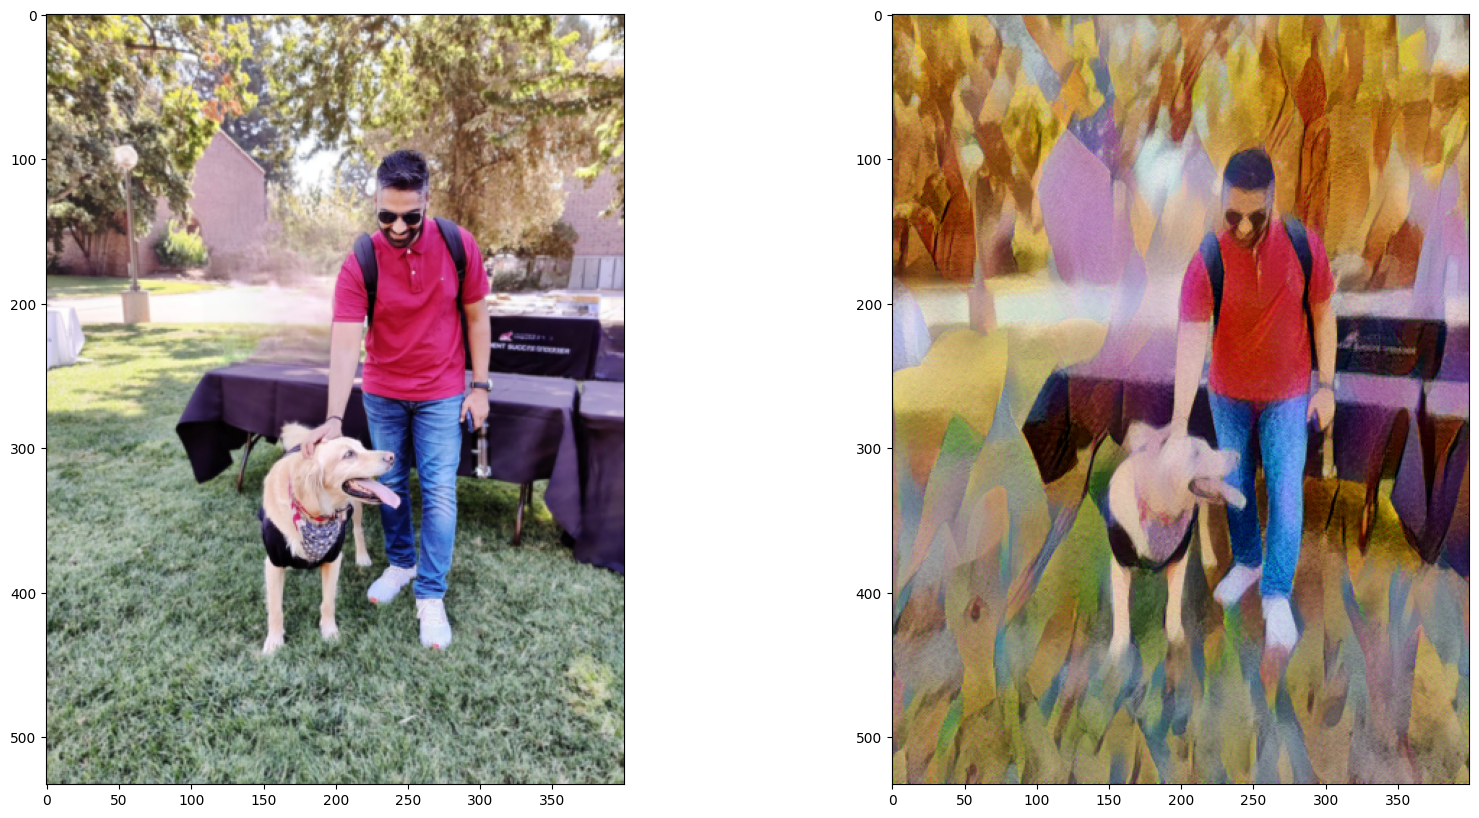

In [14]:
# display content and final, target image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(im_convert(content))
ax2.imshow(im_convert(target))